# STalign: upstream PyTorch versus squidpy JAX — Visium↔Visium affine-only

This notebook reproduces upstream's Visium slice-1 to slice-2 affine-only workflow at the pinned STalign commit and runs squidpy's JAX port beside it. Slice 1 is moving; slice 2 is fixed.

The comparison covers rasterised densities, aligned coordinates, warped densities, pointwise disagreement, and nearest-neighbour registration scores. Interpretation is deferred until all three priority workflows have been generated and executed.

## Environment

Run from the `squidpy-ports` checkout with this repository and a sibling editable squidpy checkout installed:

```bash
uv pip install -e . -e ../squidpy[jax] ipykernel
JAX_ENABLE_X64=1 MPLBACKEND=agg jupyter lab docs/notebooks/stalign-visium-affine-comparison.ipynb
```

JAX x64 is a precondition because upstream STalign is float64. Enable it through the process environment, never with `jax.config.update`.

In [1]:
from __future__ import annotations

import os
from urllib.request import urlretrieve

if os.environ.get("JAX_ENABLE_X64") != "1":
    raise RuntimeError("Restart the kernel with JAX_ENABLE_X64=1; do not toggle JAX precision inside a live process.")

import anndata as ad
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
from squidpy_ports.stalign import upstream

import squidpy as sq
from squidpy.experimental.methods.align_samples import StalignResult
from squidpy.experimental.methods.align_samples._stalign_impl._helpers import rasterize_cloud

assert jax.config.jax_enable_x64
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"upstream={upstream.UPSTREAM_SHA[:8]}  torch={torch.__version__}  jax={jax.__version__}  device={device}")

/opt/squidpy-ports/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


upstream=b2068edc  torch=2.13.0+cu130  jax=0.11.0  device=cpu


/opt/squidpy-ports/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Download upstream's published inputs

The GPL-3.0 data are downloaded from the pinned upstream commit into the ignored documentation build directory; they are not copied into this repository.

In [2]:
ports_root = upstream.vendor_root().parents[1]
data_dir = ports_root / "docs" / "_build" / "stalign-data" / "visium_data"
data_dir.mkdir(parents=True, exist_ok=True)

filenames = [
    "slice1_coor.csv",
    "slice2_coor.csv",
]
base_url = f"{upstream.UPSTREAM_URL}/raw/{upstream.UPSTREAM_SHA}/docs/visium_data"
for filename in filenames:
    destination = data_dir / filename
    if not destination.exists():
        print(f"downloading {filename}")
        urlretrieve(f"{base_url}/{filename}", destination)

print(data_dir)

/opt/squidpy-ports/docs/_build/stalign-data/visium_data


In [3]:
query_df = pd.read_csv(data_dir / filenames[0])
ref_df = pd.read_csv(data_dir / filenames[1])
query_xy_raw = query_df.iloc[:, :2].to_numpy()
ref_xy = ref_df.iloc[:, :2].to_numpy()
query_xy = query_xy_raw.copy()

print(f"moving spots={len(query_xy):,}; fixed spots={len(ref_xy):,}")

moving spots=253; fixed spots=250


## Published initialisation and rasterisation

The published Visium workflow sets `diffeo_start` beyond `niter`, so the velocity field never updates and the result is affine-only. Density rasters use `dx=1` and `blur=1` in both implementations.

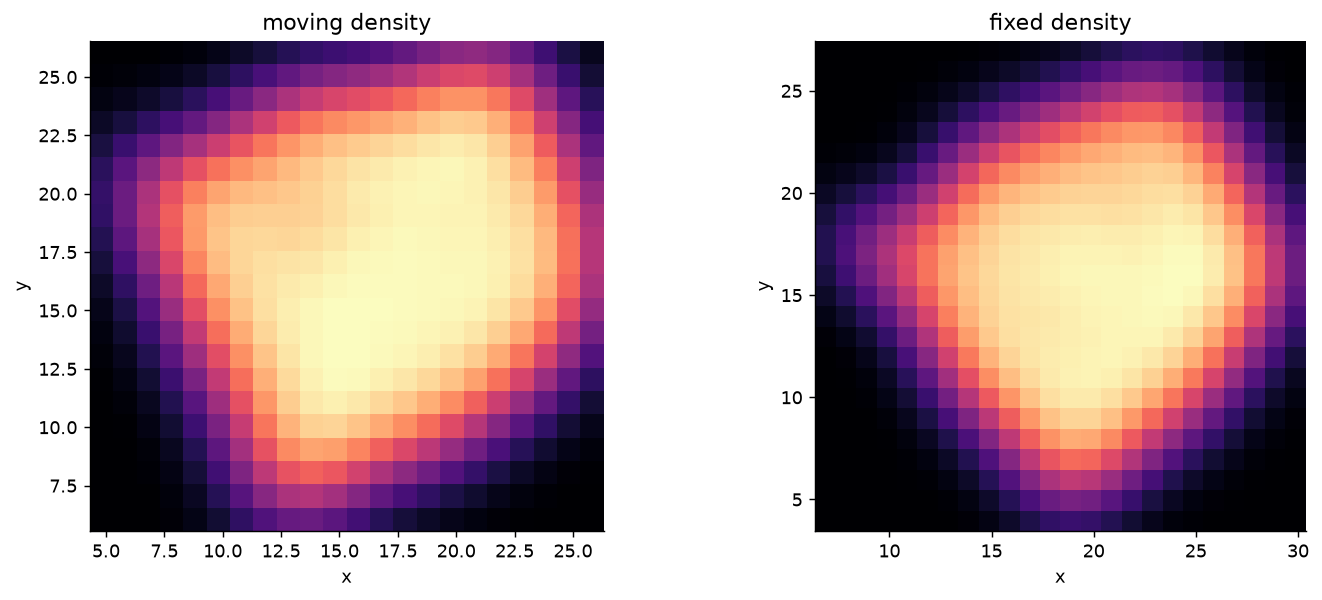

In [4]:
st = upstream.load()
x_query, y_query, density_query = st.rasterize(query_xy[:, 0], query_xy[:, 1], dx=1, blur=1, draw=0)
x_ref, y_ref, density_ref = st.rasterize(ref_xy[:, 0], ref_xy[:, 1], dx=1, blur=1, draw=0)
extent_query = st.extent_from_x((y_query, x_query))
extent_ref = st.extent_from_x((y_ref, x_ref))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, image, extent, title in zip(
    axes,
    (density_query, density_ref),
    (extent_query, extent_ref),
    ("moving density", "fixed density"),
    strict=True,
):
    ax.imshow(np.asarray(image).squeeze(), extent=extent, cmap="magma")
    ax.set(title=title, xlabel="x", ylabel="y")
    ax.invert_yaxis()
plt.show()

## Fit both implementations

The optimizer arguments are copied from the corresponding upstream notebook. Upstream calls the moving sample `I`; squidpy calls it the query.

In [5]:
fit_params = {"a": 5.0, "niter": 1_000, "diffeo_start": 1_001}
upstream_fit = st.LDDMM(
    [y_query, x_query],
    density_query,
    [y_ref, x_ref],
    density_ref,
    device=device,
    **fit_params,
)
plt.close("all")

upstream_aligned_rc = st.transform_points_source_to_target(
    upstream_fit["xv"],
    upstream_fit["v"],
    upstream_fit["A"],
    np.ascontiguousarray(query_xy[:, ::-1]),
)
upstream_aligned_xy = upstream_aligned_rc.detach().cpu().numpy()[:, ::-1]

/opt/squidpy-ports/.venv/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


/opt/squidpy-ports/vendor/STalign/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


In [6]:
query = ad.AnnData(np.empty((len(query_xy), 0)), obsm={"spatial": query_xy})
reference = ad.AnnData(np.empty((len(ref_xy), 0)), obsm={"spatial": ref_xy})
squidpy_fit = sq.experimental.tl.align(
    reference,
    query,
    in_="obsm/spatial",
    by="obs",
    method="stalign",
    dx=1,
    blur=1,
    raster_expand=1.1,
    **fit_params,
)
squidpy_aligned_xy = np.asarray(squidpy_fit.aligned_points)

## Warp both densities onto one fixed grid

For this diagnostic, squidpy's internal point-density axes are attached to the fitted result, then resampled onto upstream's fixed grid so the difference panel is pixel-aligned.

In [7]:
upstream_warped = (
    st.transform_image_source_to_target(
        upstream_fit["xv"],
        upstream_fit["v"],
        upstream_fit["A"],
        [y_query, x_query],
        density_query,
        [y_ref, x_ref],
    )
    .detach()
    .cpu()
    .numpy()
    .squeeze()
)

query_axes, squidpy_query_density = rasterize_cloud(query_xy[:, ::-1], dx=1, blur=1, expand=1.1)
ref_axes, _ = rasterize_cloud(ref_xy[:, ::-1], dx=1, blur=1, expand=1.1)
squidpy_image_fit = StalignResult(
    affine=squidpy_fit.affine,
    velocity=squidpy_fit.velocity,
    velocity_grid=squidpy_fit.velocity_grid,
    aligned_points=squidpy_fit.aligned_points,
    query_axes=query_axes,
    ref_axes=ref_axes,
)
squidpy_warped = np.asarray(squidpy_image_fit.warp_image(squidpy_query_density)).squeeze()

onto_upstream_grid = RegularGridInterpolator(
    tuple(np.asarray(axis) for axis in ref_axes), squidpy_warped, bounds_error=False, fill_value=0.0
)
yy, xx = np.meshgrid(y_ref, x_ref, indexing="ij")
squidpy_warped_common = onto_upstream_grid(np.stack([yy, xx], axis=-1))


def unit_peak(image: np.ndarray) -> np.ndarray:
    """Scale an image to unit peak magnitude."""
    image = np.asarray(image, dtype=float)
    return image / max(float(np.max(np.abs(image))), np.finfo(float).tiny)


upstream_warped_norm = unit_peak(upstream_warped)
squidpy_warped_norm = unit_peak(squidpy_warped_common)
density_difference = np.abs(upstream_warped_norm - squidpy_warped_norm)

/opt/squidpy-ports/.venv/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


## Numerical agreement and side-by-side result

There are no paired landmarks in this upstream workflow, so registration quality is summarized by symmetric nearest-neighbour distances between the aligned moving and fixed clouds.

In [8]:
def relative_l2(actual: np.ndarray, expected: np.ndarray) -> float:
    """Return relative L2 error with a safe denominator."""
    denominator = max(float(np.linalg.norm(expected)), np.finfo(float).tiny)
    return float(np.linalg.norm(actual - expected) / denominator)


def nearest_distances(moving: np.ndarray, fixed: np.ndarray) -> np.ndarray:
    """Return distances from each moving point to its nearest fixed point."""
    return cKDTree(fixed).query(moving, workers=-1)[0]


point_delta = np.linalg.norm(upstream_aligned_xy - squidpy_aligned_xy, axis=1)
upstream_nn = nearest_distances(upstream_aligned_xy, ref_xy)
squidpy_nn = nearest_distances(squidpy_aligned_xy, ref_xy)
metrics = pd.Series(
    {
        "aligned points relative L2": relative_l2(squidpy_aligned_xy, upstream_aligned_xy),
        "aligned points median |Δ|": float(np.median(point_delta)),
        "aligned points p95 |Δ|": float(np.quantile(point_delta, 0.95)),
        "upstream fixed-NN median": float(np.median(upstream_nn)),
        "squidpy fixed-NN median": float(np.median(squidpy_nn)),
        "warped density relative L2": relative_l2(squidpy_warped_norm, upstream_warped_norm),
    },
    name="value",
).to_frame()
metrics

,value
aligned points relative L2,0.000783
aligned points median |Δ|,0.020372
aligned points p95 |Δ|,0.020488
upstream fixed-NN median,0.483388
squidpy fixed-NN median,0.467520
warped density relative L2,0.016129


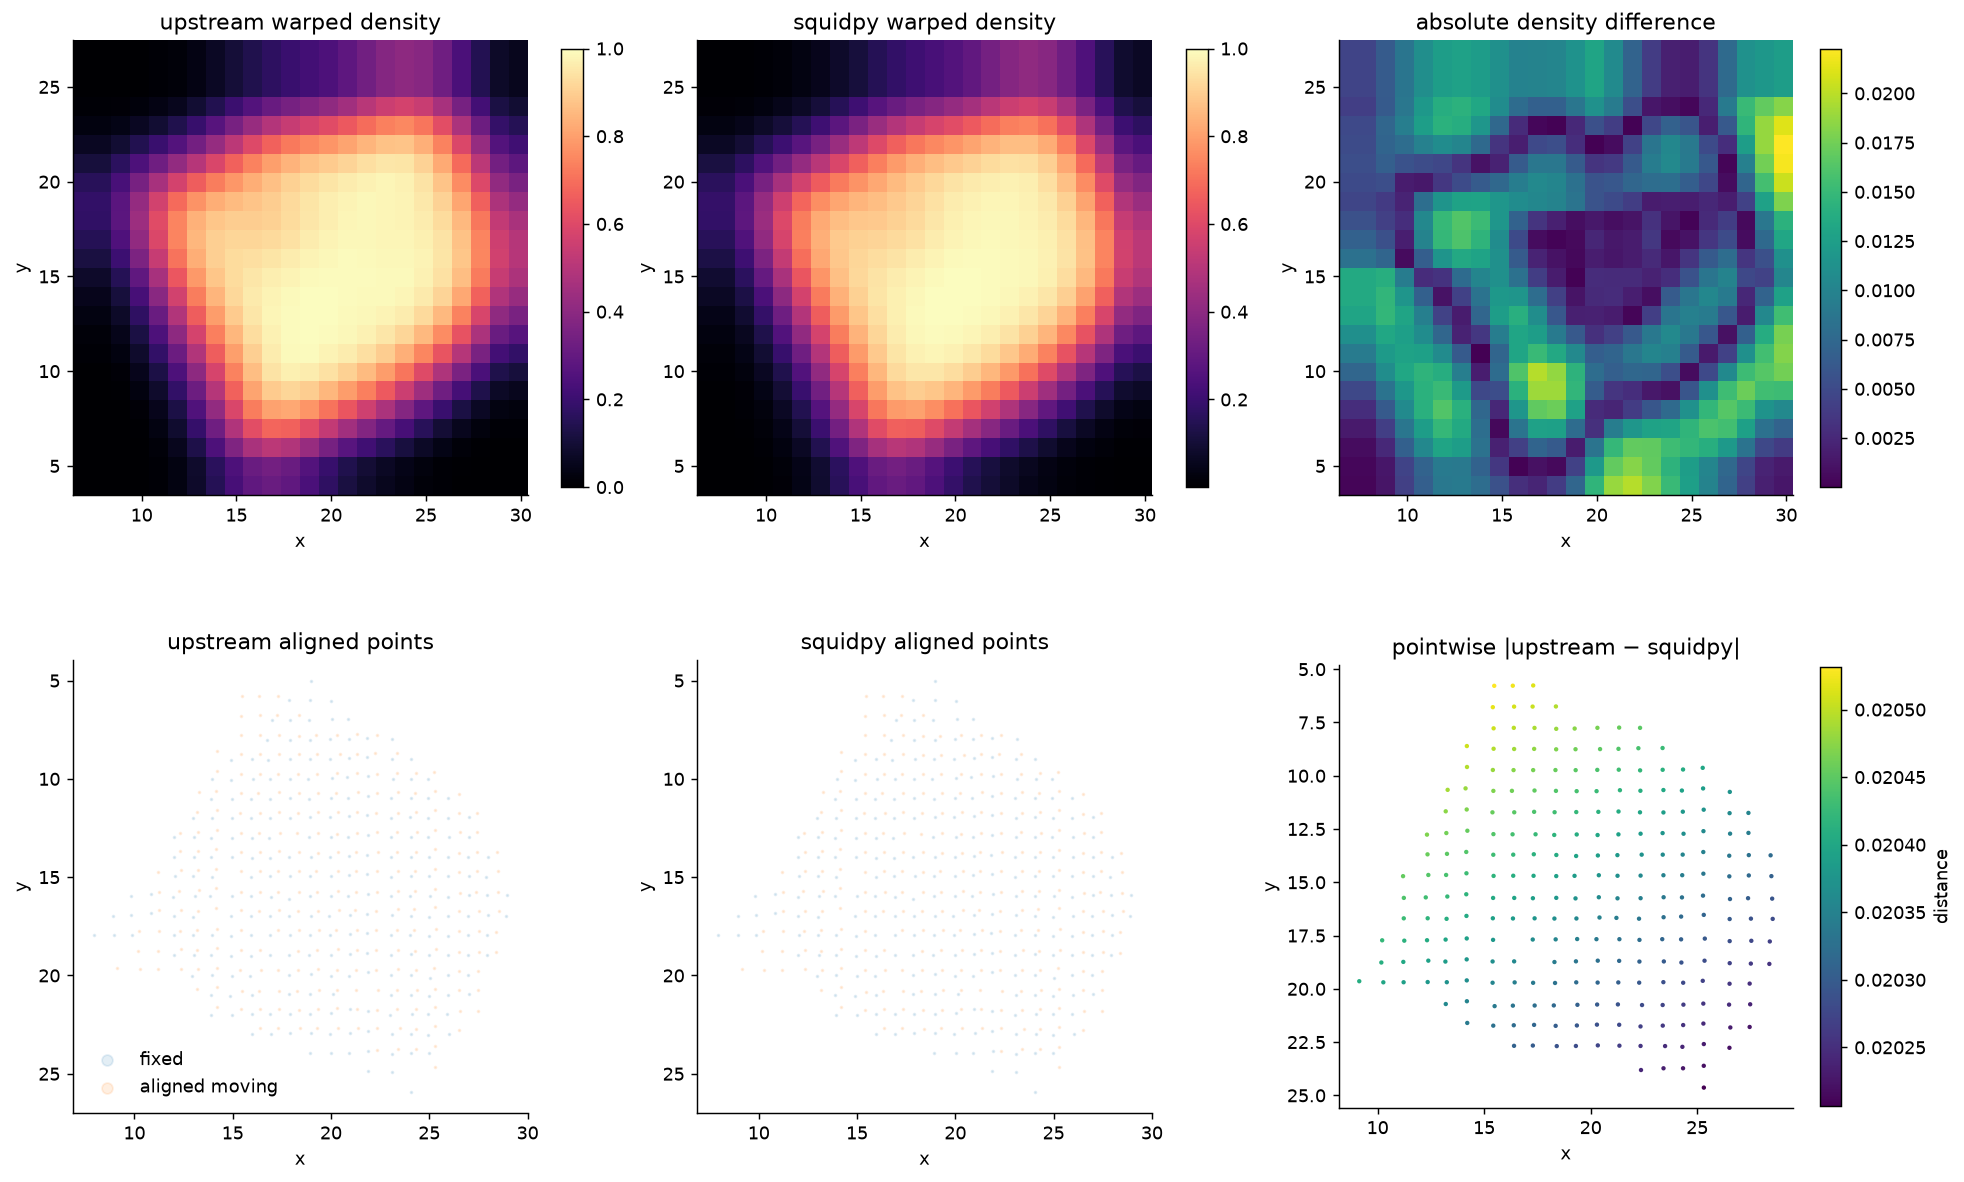

In [9]:
rng = np.random.default_rng(0)
sample = np.sort(rng.choice(len(query_xy), size=min(20_000, len(query_xy)), replace=False))
fixed_sample = np.sort(rng.choice(len(ref_xy), size=min(20_000, len(ref_xy)), replace=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5), constrained_layout=True)
for ax, image, title, cmap in zip(
    axes[0],
    (upstream_warped_norm, squidpy_warped_norm, density_difference),
    ("upstream warped density", "squidpy warped density", "absolute density difference"),
    ("magma", "magma", "viridis"),
    strict=True,
):
    artist = ax.imshow(image, extent=extent_ref, cmap=cmap)
    ax.set(title=title, xlabel="x", ylabel="y")
    ax.invert_yaxis()
    fig.colorbar(artist, ax=ax, shrink=0.75)

for ax, aligned, title in zip(
    axes[1, :2],
    (upstream_aligned_xy, squidpy_aligned_xy),
    ("upstream aligned points", "squidpy aligned points"),
    strict=True,
):
    ax.scatter(ref_xy[fixed_sample, 0], ref_xy[fixed_sample, 1], s=1, alpha=0.12, label="fixed")
    ax.scatter(aligned[sample, 0], aligned[sample, 1], s=1, alpha=0.12, label="aligned moving")
    ax.set(title=title, xlabel="x", ylabel="y", aspect="equal")
    ax.invert_yaxis()
axes[1, 0].legend(markerscale=6, frameon=False)

delta_artist = axes[1, 2].scatter(
    upstream_aligned_xy[sample, 0],
    upstream_aligned_xy[sample, 1],
    c=point_delta[sample],
    s=2,
    cmap="viridis",
)
axes[1, 2].set(title="pointwise |upstream − squidpy|", xlabel="x", ylabel="y", aspect="equal")
axes[1, 2].invert_yaxis()
fig.colorbar(delta_artist, ax=axes[1, 2], label="distance", shrink=0.75)
plt.show()

## Interpretation

This notebook intentionally records measurements without declaring tolerances. Divergences will be assessed only after the Xenium, MERFISH, and Visium workflows have all been generated and executed under the same environment.

In [10]:
try:
    from watermark import watermark as _watermark

    print(_watermark(packages="squidpy,squidpy_ports,jax,jaxlib,torch", python=True, machine=True))
except Exception as _exc:  # noqa: BLE001 - a version stamp must never fail the run
    print(f"watermark unavailable: {_exc}")

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

squidpy      : 1.8.3.dev0
squidpy_ports: 0.0.1
jax          : 0.11.0
jaxlib       : 0.11.0
torch        : 2.13.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 5.14.0-570.25.1.el9_6.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 224
Architecture: 64bit

